## ДЗ

1. Разобраться, как использовать мультииндексные ключи в датафреймах и как получить доступ к конкретному столбцу, строке

In [39]:
import pandas as pd
index = [
    ('city_1', 2010),
    ('city_1', 2020),
    ('city_2', 2010),
    ('city_2', 2020),
    ('city_3', 2010),
    ('city_3', 2020),
]

population = [
    101,
    201,
    102,
    202,
    103,
    203,
]
pop = pd.Series(population, index = index)
pop_df = pd.DataFrame(
    {
        'total': pop,
        'something': [
            10,
            11,
            12,
            13,
            14,
            15,
        ]
    }
)

index = pd.MultiIndex.from_tuples(index)
pop_df = pop_df.reindex(index)

print(pop_df)
print(pop_df.loc['city_1', 'something'])
print(pop_df.loc[['city_1', 'city_3'], ['total', 'something']])
print(pop_df.loc[['city_1', 'city_3'], 'something'])

             total  something
city_1 2010    101         10
       2020    201         11
city_2 2010    102         12
       2020    202         13
city_3 2010    103         14
       2020    203         15
2010    10
2020    11
Name: something, dtype: int64
             total  something
city_1 2010    101         10
       2020    201         11
city_3 2010    103         14
       2020    203         15
city_1  2010    10
        2020    11
city_3  2010    14
        2020    15
Name: something, dtype: int64


2. Из получившихся данных выбрать данные по 1) 2020 году для всех столбцов 2) job1 для всех строк 3) для сити1 и job2

In [80]:
print(pop_df.loc[(slice(None), 2020), :])
print('------')
index = pd.MultiIndex.from_product(
    [
        ['city_1', 'city_2'],
        [2010, 2020,]
    ],
    names=['city', 'year']
)
columns = pd.MultiIndex.from_product(
    [
        ['person_1', 'person_2', 'person_3'],
        ['job_1', 'job_2']
    ],
    names=['worker', 'job']
)

df = pd.DataFrame(columns=columns, index=index)
print(df[:]['job_1'])
print('----------')
print(df.loc['city_1'][:]['job_2'])

             total  something
city_1 2020    201         11
city_2 2020    202         13
city_3 2020    203         15
------
job         job_1 job_1 job_1
city   year                  
city_1 2010   NaN   NaN   NaN
       2020   NaN   NaN   NaN
city_2 2010   NaN   NaN   NaN
       2020   NaN   NaN   NaN
----------
job  job_2 job_2 job_2
year                  
2010   NaN   NaN   NaN
2020   NaN   NaN   NaN


3. Выполнить запрос на получение следующих данных
- все данные по person_1 и person_3
- все данные по первому городу и первым двум person-ам (с использование срезов)

Приведите пример (самостоятельно) с использованием pd.IndexSlice

In [116]:
print(df['person_1'])
print('----------')
print(df['person_3'])
print('----------')
idx = pd.IndexSlice
print(df.loc[idx['city_1', :], idx['person_1':'person_2',:]])
print('------------')
print(df.loc[idx['city_1':'city_2', 2010], idx['person_2':'person_3', 'job_2']])

job         job_1 job_2
city   year            
city_1 2010   NaN   NaN
       2020   NaN   NaN
city_2 2010   NaN   NaN
       2020   NaN   NaN
----------
job         job_1 job_2
city   year            
city_1 2010   NaN   NaN
       2020   NaN   NaN
city_2 2010   NaN   NaN
       2020   NaN   NaN
----------
worker      person_1       person_2      
job            job_1 job_2    job_1 job_2
city   year                              
city_1 2010      NaN   NaN      NaN   NaN
       2020      NaN   NaN      NaN   NaN
------------
worker      person_2 person_3
job            job_2    job_2
city   year                  
city_1 2010      NaN      NaN
city_2 2010      NaN      NaN


4. Привести пример использования inner и outer джойнов для Series (данные примера скорее всего нужно изменить)

In [138]:
ser1 = pd.Series(['a', 'b', 'c'], index=['1','2','3'])
ser2 = pd.Series(['b', 'c', 'f'], index=['1','2','4'])
s = pd.concat([ser1, ser2], axis=1, join='outer')
s2 = pd.concat([ser1, ser2], axis=1, join='inner')
print (s)
print(s2)

     0    1
1    a    b
2    b    c
3    c  NaN
4  NaN    f
   0  1
1  a  b
2  b  c


----

### Pandas продолжение

Если размерность данных больше 2, то используют иерархическую индексацию (мультииндекс). В один индекс включается несколько уровней.

In [1]:
import pandas as pd
index = [('city1', 2010), ('city1', 2020), ('city2', 2010), ('city2', 2020), ('city3', 2010), ('city3', 2020)]

population = [
    101,
    201,
    102,
    202,
    103,
    203,
]

pop = pd.Series(population, index = index)
print(pop)
print(pop[ [i for i in pop.index if i[1] == 2020] ])

(city1, 2010)    101
(city1, 2020)    201
(city2, 2010)    102
(city2, 2020)    202
(city3, 2010)    103
(city3, 2020)    203
dtype: int64
(city1, 2020)    201
(city2, 2020)    202
(city3, 2020)    203
dtype: int64


Существует класс MultiIndex. Позволяет как в экселе сделать объединенную ячейку, содержащую два индекса  
Метод reindex позволяет переопределить индекс для series

Метод unstack позволяет от мультииндексной серии перейти к датафрейму, обратное преобразование позволяет получить метод stack

In [6]:
index = pd.MultiIndex.from_tuples(index)
pop = pop.reindex(index)
print(pop)

print(pop[:, 2020])
pop_df = pop.unstack()
print(pop_df)

city1  2010    101
       2020    201
city2  2010    102
       2020    202
city3  2010    103
       2020    203
dtype: int64
city1    201
city2    202
city3    203
dtype: int64
       2010  2020
city1   101   201
city2   102   202
city3   103   203


Добавим еще одно измерение

In [2]:
index = [('city1', 2010, 1),
         ('city1', 2010, 2),

         ('city1', 2020, 1),
         ('city1', 2020, 2),

         ('city2', 2010, 1),
         ('city2', 2010, 2),

         ('city2', 2020, 1),
         ('city2', 2020, 2),

         ('city3', 2010, 1), 
         ('city3', 2010, 2),
         
         ('city3', 2020, 1), 
         ('city3', 2020, 2)]

population = [
    101,
    1010,
    201,
    2010,
    102,
    1020,
    202,
    2020,
    103,
    1030,
    203,
    2030
]
pop = pd.Series(population, index = index)
index = pd.MultiIndex.from_tuples(index)
pop = pop.reindex(index)
print(pop[:, :, 2]) # все города все года и двоечки
# pop_df = pop.unstack().unstack()



city1  2010    1010
       2020    2010
city2  2010    1020
       2020    2020
city3  2010    1030
       2020    2030
dtype: int64


In [25]:
index = [('city1', 2010, 1),
         ('city1', 2010, 2),

         ('city1', 2020, 1),
         ('city1', 2020, 2),

         ('city2', 2010, 1),
         ('city2', 2010, 2),

         ('city2', 2020, 1),
         ('city2', 2020, 2),

         ('city3', 2010, 1), 
         ('city3', 2010, 2),
         
         ('city3', 2020, 1), 
         ('city3', 2020, 2)]

population = [
    101,
    1010,
    201,
    2010,
    102,
    1020,
    202,
    2020,
    103,
    1030,
    203,
    2030
]
pop = pd.Series(population, index = index)
index = pd.MultiIndex.from_tuples(index)
pop_df = pd.DataFrame(
    {
        'total': pop,
        'smth': [i for i in range(len(population))]
    },
    index = index)
print(pop_df)
print(pop_df.loc[['city1', 'city3'], 'smth'])

              total  smth
city1 2010 1    101     0
           2   1010     1
      2020 1    201     2
           2   2010     3
city2 2010 1    102     4
           2   1020     5
      2020 1    202     6
           2   2020     7
city3 2010 1    103     8
           2   1030     9
      2020 1    203    10
           2   2030    11
city1  2010  1     0
             2     1
       2020  1     2
             2     3
city3  2010  1     8
             2     9
       2020  1    10
             2    11
Name: smth, dtype: int64


#### Как можно создавать мультииндексы?
1) Список массивов, которые задают значение индекса на каждом уровне

2) список кортежей, задающих значение индекса в каждой точке (аналогично)
3) декартово произведение обычных индексов
4) описание внутреннего представления: levels - список списков; codes - список списков меток 

In [31]:
index = pd.MultiIndex.from_arrays(
    [
       ['a', 'a', 'b', 'b'],
        [1, 2, 1, 2]
    ]
)
print(index)

#3
i3 = pd.MultiIndex.from_product([['a', 'b'], [1, 2]])
print(i3)

#4
i4 = pd.MultiIndex(levels = [['a', 'b'], [1, 2]], codes = [[0, 0, 1, 1], [0, 1, 0, 1]]) # a a b b
                                                                                        # 1 2 1 2
print(i4)

MultiIndex([('a', 1),
            ('a', 2),
            ('b', 1),
            ('b', 2)],
           )
MultiIndex([('a', 1),
            ('a', 2),
            ('b', 1),
            ('b', 2)],
           )
MultiIndex([('a', 1),
            ('a', 2),
            ('b', 1),
            ('b', 2)],
           )


Уровням можно задавать названия. 

In [34]:
data = {
    ('city1', 2010): 100,
    ('city1', 2020): 231,
    ('city2', 2010): 100,
    ('city2', 2020): 332100,

}
s = pd.Series(data)
s.index.names = ['city', 'year']
print(s)

city   year
city1  2010       100
       2020       231
city2  2010       100
       2020    332100
dtype: int64


Также мультииндексы можно получать для столбцов
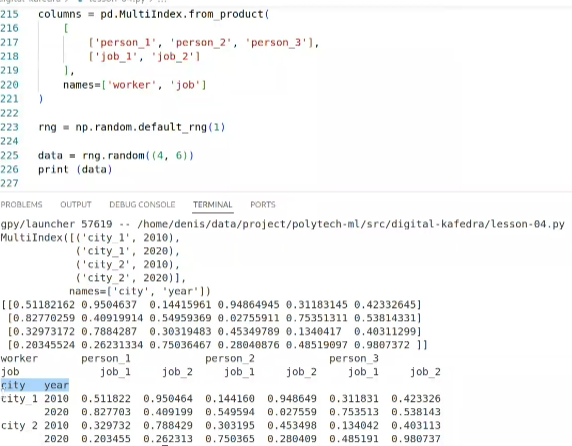
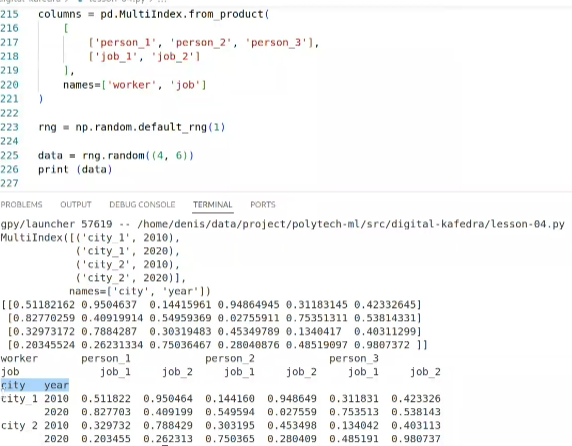

In [42]:
index = pd.MultiIndex.from_arrays(
    [
       ['city1', 'city2'],
        [1, 2]
    ], names= ['city', 'year']
)
columns = pd.MultiIndex.from_product
print(index)

MultiIndex([('city1', 1),
            ('city2', 2)],
           names=['city', 'year'])


### Индексация и срезы по мультииндексу

In [36]:
data = {
    ('city1', 2010): 100,
    ('city1', 2020): 231,
    ('city2', 2010): 100,
    ('city2', 2020): 332100,

}
s = pd.Series(data)
s.index.names = ['city', 'year']
print(s)
print(s[:, 2010])
# print(s[(s > 200)])

city   year
city1  2010       100
       2020       231
city2  2010       100
       2020    332100
dtype: int64
city
city1    100
city2    100
dtype: int64


### Перегруппировка мультииндексов 

Список a,c,d должен быть отсортирован, если мы хотим взять срез [a: b]

У метода unstack есть параметр level = (0, 1, 2) - можем менять в той последовательности, в которой хотим

In [62]:
import numpy as np
index = pd.MultiIndex.from_product(
    [
        ['a', 'c', 'b'],
        [1, 2]
    ]
)
data = pd.Series(np.random.randint(0, 10, 6), index = index)
data.index.names = ['char', 'int']
print(data)
data = data.sort_index()
print(data['a':'b'])


index = [('city1', 2010, 1),
         ('city1', 2010, 2),

         ('city1', 2020, 1),
         ('city1', 2020, 2),

         ('city2', 2010, 1),
         ('city2', 2010, 2),

         ('city2', 2020, 1),
         ('city2', 2020, 2),

         ('city3', 2010, 1), 
         ('city3', 2010, 2),
         
         ('city3', 2020, 1), 
         ('city3', 2020, 2)]

population = [
    101,
    1010,
    201,
    2010,
    102,
    1020,
    202,
    2020,
    103,
    1030,
    203,
    2030
]
pop = pd.Series(population, index = index)
index = pd.MultiIndex.from_tuples(index)
pop_df = pd.DataFrame(
    {
        'total': pop,
        'smth': [i for i in range(len(population))],
        'new1': [i**2 for i in range(len(population))]
    },
    index = index)

pop_df.unstack(level = 2)
print(pop_df)

char  int
a     1      6
      2      0
c     1      5
      2      2
b     1      6
      2      7
dtype: int32
char  int
a     1      6
      2      0
b     1      6
      2      7
dtype: int32
              total  smth  new1
city1 2010 1    101     0     0
           2   1010     1     1
      2020 1    201     2     4
           2   2010     3     9
city2 2010 1    102     4    16
           2   1020     5    25
      2020 1    202     6    36
           2   2020     7    49
city3 2010 1    103     8    64
           2   1030     9    81
      2020 1    203    10   100
           2   2030    11   121


Существует контатенация сериесов. Есть параметр verify_integrity, ignore_index, keys, join. Разобраться, что делают

In [128]:
s1 = pd.Series(['a', 'b', 'c'], index = [1,2,3])
s2 = pd.Series(['d', 'e', 'f'], index = [1,5,6])
print(pd.concat([s1, s2], verify_integrity=False))
print(pd.concat([s1, s2], keys = ['x', 'y'], join='inner'))
print(pd.concat([s1, s2], ignore_index=True))


1    a
2    b
3    c
1    d
5    e
6    f
dtype: object
x  1    a
   2    b
   3    c
y  1    d
   5    e
   6    f
dtype: object
0    a
1    b
2    c
3    d
4    e
5    f
dtype: object
